In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# 2pt

In [2]:
# Public latest data vector file
pub = fits.open('../2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate_newbins.fits')

# Our measurement: matched version with Elisa
our = fits.open('../data/dv/real_2pt_desy3_unblind_g2flip_matchElisa_2025Mar10.fits')


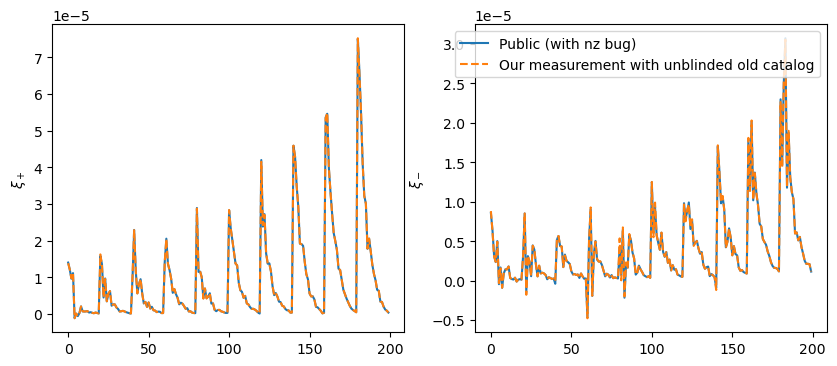

In [3]:
fig, axes = plt.subplots(1,2,figsize=(10, 4))
for i in range(2):
    axes[i].plot(pub[i+2].data['VALUE'], label='Public (with nz bug)')
    axes[i].plot(our[i+2].data['VALUE'], label='Our measurement with unblinded old catalog', ls='--')
    axes[i].set_ylabel(r'$\xi_{}$'.format(['+','-'][i]))
axes[1].legend()
plt.show()

# Map3

We do not have public one, but let's compare with the blinded one
to see there is no severe difference.

In [4]:
# Unblind (no scale cut)
unblind = fits.open('../data/dv/real_map3_desy3_unblind_796simcov_2025Mar7.fits')

# Unblind (w/ scale cut) updated on Mar 11
unblind_sc = fits.open('../data/dv/real_map3_desy3_unblind_scalecut3pcf_796simcov_2025Mar11.fits')

# Blind (sompz v04)
blind = fits.open('../data/dv/real_map3_desy3_blind_FEBRUARY2025_796simcov.fits')


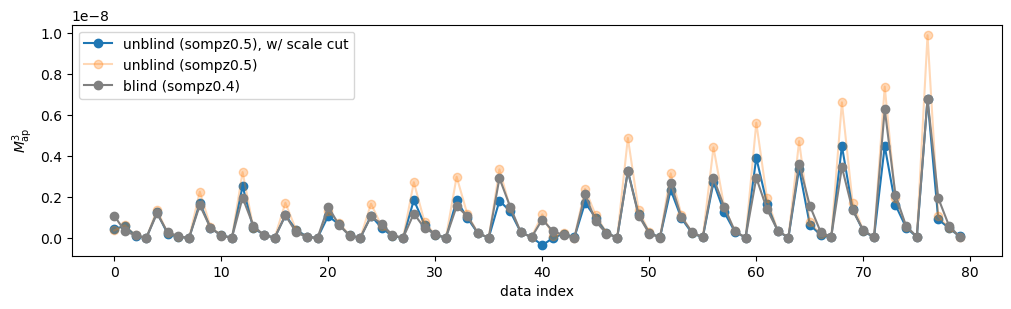

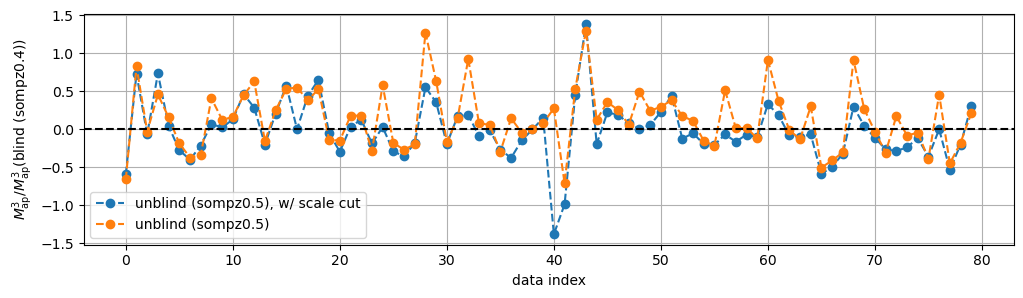

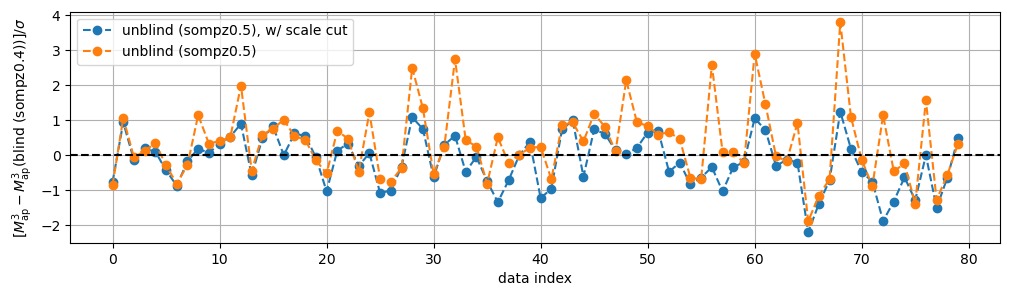

In [28]:
# Raw signal
plt.figure(figsize=(12,3))
plt.plot(unblind_sc[1].data['VALUE'], label='unblind (sompz0.5), w/ scale cut', marker='o')
plt.plot(unblind[1].data['VALUE'], label='unblind (sompz0.5)', marker='o', alpha=0.3)
plt.plot(blind[1].data['VALUE'], label='blind (sompz0.4)', marker='o', color='gray')
plt.ylabel(r'$M_{\rm ap}^3$')
plt.xlabel(r'data index')
plt.legend()
plt.show()

# Fractional diff
plt.figure(figsize=(12,3))
plt.plot(unblind_sc[1].data['VALUE']/blind[1].data['VALUE']-1, ls='--', label='unblind (sompz0.5), w/ scale cut', marker='o')
plt.plot(unblind[1].data['VALUE']/blind[1].data['VALUE']-1, ls='--', label='unblind (sompz0.5)', marker='o')
plt.ylabel(r'$M_{\rm ap}^3/M_{\rm ap}^3$(blind (sompz0.4))')
plt.xlabel(r'data index')
plt.legend()
plt.axhline(0.0, color='k', ls='--')
plt.grid()
plt.show()

# Relative to stat sigma
plt.figure(figsize=(12,3))
sigma = np.diag(unblind_sc[2].data)**0.5
plt.plot((unblind_sc[1].data['VALUE']-blind[1].data['VALUE'])/sigma, ls='--', label='unblind (sompz0.5), w/ scale cut', marker='o')
plt.plot((unblind[1].data['VALUE']-blind[1].data['VALUE'])/sigma, ls='--', label='unblind (sompz0.5)', marker='o')
plt.ylabel(r'$[M_{\rm ap}^3-M_{\rm ap}^3(\text{blind (sompz0.4)})]/\sigma$')
plt.xlabel(r'data index')
plt.legend()
plt.axhline(0.0, color='k', ls='--')
plt.grid()
plt.show()